In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Step 1: Basic EDA(Exploratory Data Analysis)


In [2]:
#Load the dataset
# df = dataframe 
df = pd.read_csv("Crop_recommendation.csv")

In [3]:
#print df by typing df or print (df) 
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

##
Checking the Missing Values

In [7]:
#checking null values of dataset
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [8]:
#Checking the null values at once
df.isna().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [9]:
#Checking the datatypes(we have our input should be in numeric from like float int(n,p,k,temp,h,ph,rainfall) and the label must be categorical ; it means label should of object datatypes
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [10]:
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool

In [11]:
#Checking if there is duplicated row in dataset or not if total = 0 then no duplicated row in dataset
duplicated_count = df.duplicated().sum()
print (duplicated_count)


0


In [12]:
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64

In [13]:
#only describe numeric column i.e cannot describe label which is non-numeric(object ho tesko lagi xuttai function use garnu paryo jun tala gareyxam)
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
label_counts = df['label'].value_counts()
print (label_counts)

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


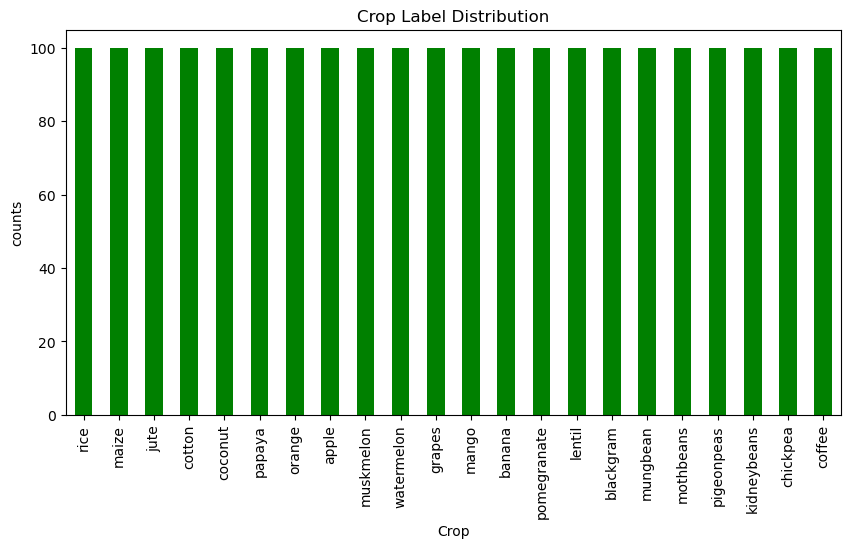

In [15]:
plt.figure(figsize=(10,5))
label_counts.plot(kind ='bar', color='Green')
plt.title("Crop Label Distribution")
plt.xlabel("Crop")
plt.ylabel("counts")
plt.show()

#### Importing All algorithm from scikit learn

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

#From the imports we’ve listed, the topic is clearly about "Supervised Machine Learning Classification with Model Comparison" using Scikit-learn.
#Here’s why:
#train_test_split → Splitting dataset into training and testing sets.
#StandardScaler → Feature scaling (important for algorithms like KNN, SVM, Logistic Regression).
#accuracy_score → Model evaluation metric.
#Classifiers:       --Model building (ML models)
#DecisionTreeClassifier → Tree-based model.
#RandomForestClassifier → Ensemble of decision trees.
#KNeighborsClassifier → Distance-based model.
#LogisticRegression → Linear classification model.
#SVC → Support Vector Machine classifier.

In [17]:
df.head(3)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


In [18]:
#Input columns
X = df[['N','P','K','temperature','humidity','ph','rainfall']]

In [19]:
#Output or Targeted columns (If we put all above input we get crop as a output)
y = df[['label']]

#### Splitting Dataset into Training and Testing Sets

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#X → Input features (N, P, K, temperature, humidity, pH, rainfall)
#y → Target variable (crop label)
#test_size=0.2
#20% data goes to the test set.
#80% data goes to the training set.
#random_state=42
#Ensures the same train-test split every time you run the code.
#stratify=y
#Maintains the same proportion of each crop class in both training and testing sets.
#Very important for classification problems.

In [21]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1607,0,18,14,29.771494,92.007200,7.207991,114.416179
1212,9,122,201,29.587484,80.919344,5.570291,68.064173
362,11,71,24,21.140114,22.718235,5.606620,141.605672
566,38,38,18,26.310518,61.187491,6.294130,35.734038
1671,18,12,8,12.590940,91.816688,6.206053,119.391672
...,...,...,...,...,...,...,...
808,13,64,20,19.134577,62.575269,6.590571,36.469470
422,16,55,19,19.543141,47.191883,6.413544,192.437219
2052,82,48,36,25.793520,81.769040,6.352077,193.241838
2083,90,50,44,26.916437,73.486560,6.253409,171.471638


In [22]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
1609,13,23,6,23.961476,90.264080,7.365338,102.695870
1072,98,79,50,25.341198,84.473213,6.435917,91.064934
1912,140,38,15,24.147295,75.882986,6.021440,69.915635
100,71,54,16,22.613600,63.690706,5.749914,87.759539
1645,40,22,6,24.536101,91.909972,6.488221,115.978799
...,...,...,...,...,...,...,...
140,99,56,17,24.108592,73.131123,6.234330,71.075622
1587,1,135,203,22.778565,92.701240,5.624203,113.775922
2015,70,38,35,24.397362,79.268617,7.014064,164.269701
1254,21,134,202,10.723025,80.021306,6.425420,65.298211


In [23]:
y_train

,label
1607,orange
1212,grapes
362,kidneybeans
566,mothbeans
1671,orange
...,...
808,lentil
422,pigeonpeas
2052,jute
2083,jute


In [24]:
y_test

,label
1609,orange
1072,banana
1912,cotton
100,maize
1645,orange
...,...
140,maize
1587,apple
2015,jute
1254,grapes


#### Feature Scaling using StandardScaler

In [25]:
#Standardizes features to have mean 0 and standard deviation 1, improving the performance of distance-based models such as KNN and SVM.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
#Print scaled x train
X_train_scaled

array([[-1.37162846, -1.07290957, -0.67351002, ...,  0.92439516,
         0.93754456,  0.1994396 ],
       [-1.12741063,  2.08451298,  3.01526081, ...,  0.42661263,
        -1.15384595, -0.64367687],
       [-1.07314   ,  0.53616154, -0.47624954, ..., -2.18629069,
        -1.10745175,  0.69400094],
       ...,
       [ 0.8534673 , -0.1621146 , -0.23953698, ...,  0.46475923,
        -0.15548263,  1.63323326],
       [ 1.07054981, -0.10139494, -0.0817286 , ...,  0.09292232,
        -0.28148439,  1.23724576],
       [-1.34449314,  2.3881113 ,  2.99553476, ...,  0.51745   ,
        -1.08941335, -0.67077084]], shape=(1760, 7))

In [27]:
#Converting scaled x_train output (arrays) to tabular form using pandas (Dataframe) and take columns from X_train variablesa
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [28]:
X_train_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941
...,...,...,...,...,...,...,...
1755,-1.018869,0.323643,-0.555154,-1.274842,-0.396933,0.149081,-1.218366
1756,-0.937463,0.050404,-0.574880,-1.194399,-1.087561,-0.076988,1.618598
1757,0.853467,-0.162115,-0.239537,0.036250,0.464759,-0.155483,1.633233
1758,1.070550,-0.101395,-0.081729,0.257343,0.092922,-0.281484,1.237246


#### Models Dictionary

In [29]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42),
    "Desicison Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200,random_state=42),
    "SVM(RBF Kernel)": SVC(kernel='rbf',random_state=42)
}

In [30]:
results = []

for name, model in models.items():

    if name in ["KNN", "Logistic Regression", "SVM(RBF Kernel)"]:
        model.fit(X_train_scaled, y_train.squeeze()) # Model Training
        preds = model.predict(X_test_scaled)  # Model Prediction
    else:
        model.fit(X_train, y_train.squeeze())
        preds = model.predict(X_test)

    # Model Evaluation -> Accuracy Calculation
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

In [31]:
print ("The accuracy is :")
results

The accuracy is :


[('Random Forest', 0.9954545454545455),
 ('Desicison Tree', 0.9795454545454545),
 ('KNN', 0.9795454545454545),
 ('Logistic Regression', 0.9727272727272728),
 ('SVM(RBF Kernel)', 0.9840909090909091)]

In [32]:
#Tabular form ma print gardeyko using pandas aru kei haina mathi ko step ko same result ho 
results_df = pd.DataFrame(results,columns=["Model","Accuracy"])
results_df

,Model,Accuracy
0,Random Forest,0.995455
1,Desicison Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727
4,SVM(RBF Kernel),0.984091


In [37]:
#Sorting gareyko jun ko accuracy dherai xa tyo suruma aawos manually check garna naparos vanera ho..ailey po 5 ota lexam sajilo vaxa paxi dherai algorithm use garda sorting ekdam kam lagxa
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df  #printing we can use print(results_df) or results_df only to print results_df values

,Model,Accuracy
0,Random Forest,0.995455
4,SVM(RBF Kernel),0.984091
1,Desicison Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727


In [47]:
import pickle as pkl

In [48]:
#We use multiple model above but now we are using only the best model i.e Random Forest
best_model =  RandomForestClassifier(n_estimators=200,random_state=42)
best_model.fit(X_train,y_train.squeeze())
preds = best_model.predict(X_test)
acc = accuracy_score(y_test,preds)   #comparing y_test and prediction(preds) to see how similar does our model predict the output on test(input test) dataset
print(f"Best model accuracy: {acc}")  # we are using f string because we are using variables acc on the print statement so.


Best model accuracy: 0.9954545454545455


In [49]:
best_model.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [50]:
bundle ={
    "Model" : best_model,
    "Features_cols" : ['N','P','K','temperature','humidity','ph','rainfall'],
    "Classes" :best_model.classes_
}

In [51]:
#Write and save data in pickle file(f)
with open('Crop_recommendation_RF.pkl','wb') as f:
    pkl.dump(bundle,f)
    print("Model saved as Crop_recommendation_RF.pkl")


#Yetti maee sakkayeni hunxa hai ..no need to perform tala ko code 

Model saved as Crop_recommendation_RF.pkl


In [53]:
#Read to load the pickle file for generating prediction here to check our prediction here as well,Ultimately we are going to predict in webdashboard but here check only if the model gice right prediction or not (code is right or not)
with open('Crop_recommendation_RF.pkl','rb') as f:
    b = pkl.load(f)


In [56]:
print(type(b["Model"]))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [58]:
print(b["Model"])

RandomForestClassifier(n_estimators=200, random_state=42)


In [78]:
sample = {'N':40, 'P':35, 'K':20, 'temperature':27, 'humidity':77, 'ph':6, 'rainfall':400}
X = [[sample[c] for c in b["Features_cols"]]]      # b ko though feature columns ko data(n,p....) one by one c ma load hunxa ani c ko features ma sample ko value add hunxa jun chai x variables ma store vayera basxa 
print(X)

[[70, 35, 20, 27, 77, 6, 400]]


In [81]:
print("Prediction:",b["Model"].predict(X)[0])

Prediction: cotton


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
